# Training 생성 · Random Forest 학습 · 잔차분산 추정

- `nonlinear_homo_gaussian`에서 training 데이터 1,000개 생성
- 입력·오차 seed는 각각 1·2, RF random_state는 100
- 앞서 OOB 탐색으로 선택한 설정을 하드 코딩하여 RF를 한 번 학습
- 720개 조합 탐색 코드는 참고용으로 모두 주석 처리하여 재실행하지 않음
- True 함수 근사 진단 후 in-sample SSE/n으로 잔차분산 추정
- Training 데이터는 `../data/training_data.csv`에 저장하며 같은 경로는 덮어쓰기
- SSE/n은 현재 임시 추정 규칙이며 불편추정량으로 확정한 것은 아님

In [1]:
import json
from pathlib import Path
from dataclasses import dataclass
from typing import Callable

import numpy as np
import pandas as pd
from scipy import stats

## 0. 설정과 seed

현재는 하나의 DGP에서 training dataset 하나를 생성하는 단계
Master seed에 서로 다른 값을 더해 입력용·오차용 seed를 구분

실제 RNG는 아래 training 생성 셀에서 초기화하므로, 동일한 설정으로 해당 셀 전체를 재실행하면 같은 데이터 재현
여러 독립 학습 실험으로 확장할 때의 반복별 seed 구성은 이후 별도 결정

In [2]:
MASTER_SEED = 0  # smoke용 임시값
N_TRAIN = 1000
TRAINING_DGP_NAME = "nonlinear_homo_gaussian"  # 현재 생성할 DGP

## 1. Error distribution

각 error는 `sample(size, rng)`, `cdf(e)`, `ppf(p)` 세 메서드를 갖는 클래스
세 메서드가 같은 표준화 상수(df, scale, a, s 등)를 공유하도록 클래스로 묶음

- `sample(size, rng)`: 실제 난수 표본 생성 — 정수 또는 shape 튜플 입력 가능
- `cdf(e)`: $P(\varepsilon\le e)$, 선택적 coverage 수치 검증에 사용
- `ppf(p)`: 분위수, 예를 들어 `ppf(0.975)`는 누적확률 97.5% 지점

세 분포 모두 $E[\varepsilon]=0$, $\mathrm{Var}(\varepsilon)=1$로 표준화
Gaussian은 정규, Student-t는 대칭 heavy tail, Lognormal은 비대칭 오차

이는 모집단 성질이며 유한 표본의 평균·분산이 정확히 0·1일 필요는 없음
True DGP 오차용 클래스이며, 후속 MC 가상 오차는 모든 scenario에서 별도의 Gaussian 생성 규칙 사용

In [3]:
class GaussianError:
    """E[eps]=0, Var(eps)=1인 표준정규 오차.

    표준정규는 원래부터 평균 0·분산 1이라 별도 변환이 필요 없음.
    """

    def sample(self, size, rng):
        # Training/calibration/true 평가에 사용할 표준정규 난수 생성
        return rng.standard_normal(size)

    def cdf(self, e):
        # Cumulative distribution function: P(eps <= e)
        return stats.norm.cdf(e)

    def ppf(self, p):
        # CDF의 역함수: P(eps <= q) = p인 q 반환
        # 예: ppf(0.975)는 누적확률 97.5% 지점
        return stats.norm.ppf(p)


class StudentTError:
    """T ~ t_df를 sqrt(df/(df-2))로 나누어 평균 0·분산 1로 표준화.

    기본값 df=3에서는 T/sqrt(3).
    """

    def __init__(self, df=3):
        if not np.isfinite(df) or df <= 2:
            raise ValueError("분산을 1로 표준화하려면 유한한 df > 2이어야 함")
        self.df = df  # 자유도가 작을수록 꼬리가 두꺼움
        # t_df의 분산은 df/(df-2)이므로 표준편차로 나누어 표준화
        self.scale = np.sqrt(df / (df - 2))

    def sample(self, size, rng):
        raw_t_sample = rng.standard_t(self.df, size=size)
        return raw_t_sample / self.scale

    def cdf(self, e):
        # eps=T/scale이므로 P(eps<=e)=P(T<=scale*e)
        e_in_original_t_scale = np.asarray(e) * self.scale
        return stats.t.cdf(e_in_original_t_scale, df=self.df)

    def ppf(self, p):
        # 원래 t분포의 분위수를 표준편차로 나누어 eps 기준으로 변환
        q_in_original_t_scale = stats.t.ppf(p, df=self.df)
        return q_in_original_t_scale / self.scale


class LogNormalError:
    """eps=(exp(Z)-a)/s, Z~N(0,1).

    a=exp(1/2), s=sqrt(e*(e-1)).
    exp(Z)의 평균을 빼고 표준편차로 나누어 평균 0·분산 1로 표준화.
    """

    def __init__(self):
        self.a = np.exp(0.5)  # exp(Z)의 평균
        self.s = np.sqrt(np.e * (np.e - 1))  # exp(Z)의 표준편차

    def sample(self, size, rng):
        z = rng.standard_normal(size)
        raw_lognormal = np.exp(z)  # 아직 평균 0·분산 1이 아닌 원래 로그정규 표본
        return (raw_lognormal - self.a) / self.s

    def cdf(self, u):
        # 1단계: eps 기준값 u를 표준화 이전의 exp(Z) 기준값으로 변환
        # eps=(exp(Z)-a)/s이므로 P(eps<=u)=P(exp(Z)<=s*u+a)
        u = np.asarray(u, dtype=float)
        original_scale_value = self.s * u + self.a

        # 2단계: exp(Z)는 항상 양수이므로 기준값이 0 이하이면 확률 0
        is_in_support = original_scale_value > 0

        # 3단계: log(0 이하)의 경고를 피하려고 support 밖에는 더미값 1 사용
        safe_value_for_log = np.where(is_in_support, original_scale_value, 1.0)

        # 4단계: exp(Z)<=val <=> Z<=log(val)이므로 표준정규 CDF 적용
        probability_if_in_support = stats.norm.cdf(np.log(safe_value_for_log))

        # 5단계: support 밖의 확률을 0으로 처리
        result = np.where(is_in_support, probability_if_in_support, 0.0)

        # 6단계: 입력이 NaN인 위치는 결과도 NaN 유지
        return np.where(np.isnan(u), np.nan, result)

    def ppf(self, p):
        # 표준정규 분위수 -> exp로 원래 스케일 -> 평균·표준편차로 표준화
        p = np.asarray(p, dtype=float)
        standard_normal_quantile = stats.norm.ppf(p)
        original_scale_value = np.exp(standard_normal_quantile)
        return (original_scale_value - self.a) / self.s


ERROR_DISTRIBUTIONS = {
    "gaussian": GaussianError(),
    "student_t": StudentTError(df=3),
    "lognormal": LogNormalError(),
}

## 2. DGP — Data Generating Process

$X=(X_1,X_2)$, $X_1,X_2\overset{iid}{\sim}U(-1,1)$, $Y=m_0(X)+\sigma_0(X)\varepsilon$

- `m0_linear`, `m0_nonlinear`: true conditional mean, 지정한 입력분포에서 평균 0·분산 4/3
- `sigma0_homo`, `sigma0_hetero`: true conditional scale, hetero는 $X_1$에만 의존
- `draw_X`, `draw_Y`: 설명변수와 반응변수 생성

두 scale 모두 모집단 평균 noise variance $E_X[\sigma_0^2(X)]=1$
고정 입력 1,000행에서 계산한 평균 true 분산은 정확히 1일 필요는 없음

In [4]:
def m0_linear(X):
    # X[:, 0], X[:, 1]은 각각 전체 관측치의 첫 번째·두 번째 변수 열
    x1, x2 = X[:, 0], X[:, 1]
    return np.sqrt(2) * (x1 + x2)


def m0_nonlinear(X):
    x1, x2 = X[:, 0], X[:, 1]
    return np.sqrt(6 / 11) * (2 * np.sin(np.pi * x1) + x2 + x1 * x2)


def sigma0_homo(X):
    return np.ones(X.shape[0])  # 모든 위치에서 noise 크기 동일


def sigma0_hetero(X):
    x1 = X[:, 0]
    # sigma0는 표준편차 함수이며, 조건부 분산은 sigma0(X)**2
    # sqrt(1.18)로 나누어 모집단 평균 noise variance를 1로 정규화
    return (0.4 + 1.2 * np.sin(np.pi * x1) ** 2) / np.sqrt(1.18)


MEAN_FUNCTIONS = {"linear": m0_linear, "nonlinear": m0_nonlinear}
SCALE_FUNCTIONS = {"homo": sigma0_homo, "hetero": sigma0_hetero}


def draw_X(n, rng):
    # (n, 2) shape, 두 열을 독립 U(-1,1)에서 생성
    return rng.uniform(-1.0, 1.0, size=(n, 2))


def draw_Y(X, mean_fn, scale_fn, error, rng):
    # 주어진 X를 그대로 사용하고 새로운 true 오차로 반응값 생성
    eps = error.sample(X.shape[0], rng)
    return mean_fn(X) + scale_fn(X) * eps


@dataclass
class DGP:
    name: str
    mean_fn: Callable
    scale_fn: Callable
    error: object
    error_name: str  # True DGP의 오차분포 식별자
    scale_name: str  # True DGP의 등분산·이분산 조건 식별자

    def sample_y(self, X, rng_eps):
        # 이미 정한 입력 X를 유지하고 반응값만 생성 — 고정 training 입력에 사용
        return draw_Y(X, self.mean_fn, self.scale_fn, self.error, rng_eps)

    def sample_xy(self, n, rng_x, rng_eps):
        # 새로운 입력과 반응값이 모두 필요한 경우 사용
        # 입력·오차 RNG를 별도 인자로 받아 stream 분리를 명시
        if rng_x is rng_eps:
            raise ValueError("입력과 오차에는 서로 다른 용도로 만든 RNG를 전달해야 함")
        X = draw_X(n, rng_x)
        Y = self.sample_y(X, rng_eps)
        return X, Y


DGPS = {}
for mean_name, mean_fn in MEAN_FUNCTIONS.items():
    for scale_name, scale_fn in SCALE_FUNCTIONS.items():
        for error_name, error in ERROR_DISTRIBUTIONS.items():
            dgp_name = f"{mean_name}_{scale_name}_{error_name}"
            DGPS[dgp_name] = DGP(
                name=dgp_name,
                mean_fn=mean_fn,
                scale_fn=scale_fn,
                error=error,
                error_name=error_name,
                scale_name=scale_name,
            )

print(f"총 {len(DGPS)}개 DGP")
list(DGPS)

총 12개 DGP


['linear_homo_gaussian',
 'linear_homo_student_t',
 'linear_homo_lognormal',
 'linear_hetero_gaussian',
 'linear_hetero_student_t',
 'linear_hetero_lognormal',
 'nonlinear_homo_gaussian',
 'nonlinear_homo_student_t',
 'nonlinear_homo_lognormal',
 'nonlinear_hetero_gaussian',
 'nonlinear_hetero_student_t',
 'nonlinear_hetero_lognormal']

## 3. Training dataset 생성

입력용·오차용 RNG를 각각 `MASTER_SEED + 1`, `MASTER_SEED + 2`로 초기화
동일한 설정으로 이 생성 셀 전체를 재실행하면 같은 입력·반응값 재현

생성한 `training_x`는 이후 학습·MC·평가에서 그대로 사용
현재 코드는 선택한 DGP 하나의 데이터 생성용이며, 12개 DGP 전체를 반복 실행하지 않음

저장 경로는 현재 작업 디렉터리 기준이며, 같은 파일명으로 재실행하면 기존 CSV를 덮어씀

In [5]:
# 동일한 설정으로 이 셀을 재실행하면 동일한 training dataset 재현
rng_train_x = np.random.default_rng(MASTER_SEED + 1)
rng_train_eps = np.random.default_rng(MASTER_SEED + 2)

training_x = draw_X(N_TRAIN, rng_train_x)
training_dgp = DGPS[TRAINING_DGP_NAME]

# Training 입력을 고정하고 별도 true 오차 stream으로 반응값 생성
training_y = training_dgp.sample_y(training_x, rng_train_eps)

print("DGP:", training_dgp.name)
print("training_x:", training_x.shape)
print("training_y:", training_y.shape)

# 학습용 데이터: point_id로 각 입력행과 training 반응값의 대응 보존
# 입력과 학습용 반응값을 하나의 DataFrame으로 관리
training_set = pd.DataFrame({
    "point_id": np.arange(training_x.shape[0]),
    "x1": training_x[:, 0],
    "x2": training_x[:, 1],
    "y": training_y,
})

# 현재 작업 디렉터리를 기준으로 ../data 폴더에 저장
# 같은 경로로 재실행하면 해당 CSV를 현재 데이터로 덮어씀
save_path = Path("../data/training_data.csv")
save_path.parent.mkdir(parents=True, exist_ok=True)

# point_id가 있으므로 DataFrame의 별도 인덱스는 저장하지 않음
training_set.to_csv(save_path, index=False)
print(f"저장 위치: {save_path}")
training_set.head()

DGP: nonlinear_homo_gaussian
training_x: (1000, 2)
training_y: (1000,)
저장 위치: ..\data\training_data.csv


,point_id,x1,x2,y
0,0,0.023643,0.900927,0.979778
1,1,-0.711681,0.897299,-1.494019
2,2,-0.376337,-0.153347,-1.850719
3,3,0.655405,-0.181602,-1.358966
4,4,0.099187,-0.944882,1.485509


## 4. 실행 설정

DGP·seed·표본 수 등 현재 데이터 생성 설정을 `smoke_config`에 기록
학습 데이터는 `point_id`, `x1`, `x2`, `y`를 포함한 CSV 하나로 저장
아래 설정은 노트북 안에 유지하며 별도 설정 파일 저장은 수행하지 않음

In [6]:
smoke_config = {
    "run_type": "smoke",
    "master_seed": MASTER_SEED,
    "master_seed_status": "temporary",
    "rng_scheme": "default_rng_with_seed_offsets",
    "train_x_seed": MASTER_SEED + 1,
    "train_eps_seed": MASTER_SEED + 2,
    "scenario": training_dgp.name,
    "n_train": N_TRAIN,
    "d": 2,
}

print(json.dumps(smoke_config, ensure_ascii=False, indent=2))

{
  "run_type": "smoke",
  "master_seed": 0,
  "master_seed_status": "temporary",
  "rng_scheme": "default_rng_with_seed_offsets",
  "train_x_seed": 1,
  "train_eps_seed": 2,
  "scenario": "nonlinear_homo_gaussian",
  "n_train": 1000,
  "d": 2
}


## 5. 간단한 확인

Shape·유한값·CDF/PPF 일관성·seed 재현성 확인
오차 표본의 평균·분산이 정확히 0·1이어야 한다는 검사는 하지 않음

이 확인은 데이터 생성 smoke 검증이며, 모델 정확도·MC 정밀도·coverage 검증은 아님

In [7]:
assert len(DGPS) == 12
assert training_x.shape == (N_TRAIN, 2)
assert training_y.shape == (N_TRAIN,)
assert np.isfinite(training_x).all()
assert np.isfinite(training_y).all()

# 필요한 꼬리 분위수에서 CDF와 PPF가 동일한 표준화를 사용하는지 확인
p_check = np.array([0.005, 0.025, 0.05, 0.5, 0.95, 0.975, 0.995])
for error_name, error in ERROR_DISTRIBUTIONS.items():
    np.testing.assert_allclose(error.cdf(error.ppf(p_check)), p_check, atol=1e-9, rtol=0)

# Lognormal support 경계와 NaN 처리 확인
lognormal = ERROR_DISTRIBUTIONS["lognormal"]
lower_support = -lognormal.a / lognormal.s
assert float(lognormal.cdf(lower_support - 1)) == 0.0
assert np.isnan(lognormal.cdf(np.nan))

# 같은 seed로 RNG를 새로 초기화하여 입력과 반응값 재현
x_reproduced = draw_X(
    N_TRAIN, np.random.default_rng(MASTER_SEED + 1)
)
y_reproduced = training_dgp.sample_y(
    x_reproduced,
    np.random.default_rng(MASTER_SEED + 2),
)
np.testing.assert_array_equal(training_x, x_reproduced)
np.testing.assert_array_equal(training_y, y_reproduced)

print("데이터 shape·유한값·CDF/PPF·seed 재현성 확인 완료")

데이터 shape·유한값·CDF/PPF·seed 재현성 확인 완료


## 6. Random Forest 학습 — 선택한 하이퍼파라미터 고정

앞서 보고한 최적 설정을 그대로 사용하여 전체 training 데이터로 한 번 학습
`max_depth=None`은 깊이 제한 없음, `max_features=1.0`은 두 변수를 모두 분할 후보로 사용

모델 학습에는 `training_x`, `training_y`만 사용하며 true 함수값은 후속 진단에만 사용
이후 MC·CP는 동일한 `fitted_model`을 공유하며 구간 생성 중 재학습하지 않음

같은 데이터·설정·random_state를 사용하되 라이브러리 버전에 따라 결과 차이가 있을 수 있음

In [8]:
from sklearn.ensemble import RandomForestRegressor

RF_RANDOM_STATE = MASTER_SEED + 100  # 데이터 생성 RNG와 구분한 모델 학습 seed

# 앞서 720개 조합의 OOB 탐색에서 선택한 설정 — 탐색을 다시 실행하지 않음
best_params = {
    "n_estimators": 1000,
    "max_depth": None,
    "min_samples_leaf": 20,
    "max_features": 1.0,
    "max_samples": 0.7,
}

fitted_model = RandomForestRegressor(
    bootstrap=True,
    oob_score=True,
    random_state=RF_RANDOM_STATE,
    n_jobs=-1,
    **best_params,
)
fitted_model.fit(training_x, training_y)

# 전체 forest의 in-sample 예측 — OOB 예측과 구분
train_pred = fitted_model.predict(training_x)

# 같은 training 관측치에 대해, 각 행을 학습하지 않은 트리들로 얻은 OOB 예측
# 하이퍼파라미터 재탐색 없이 현재 모델의 참고 진단만 계산
if not np.isfinite(fitted_model.oob_prediction_).all():
    raise ValueError("OOB 예측에 비유한 값이 존재합니다")
oob_rmse = float(np.sqrt(np.mean((training_y - fitted_model.oob_prediction_) ** 2)))

print("고정 RF 하이퍼파라미터:", best_params)
print(f"현재 모델 OOB RMSE: {oob_rmse:.10f}")
print(f"현재 모델 OOB R2: {fitted_model.oob_score_:.10f}")

고정 RF 하이퍼파라미터: {'n_estimators': 1000, 'max_depth': None, 'min_samples_leaf': 20, 'max_features': 1.0, 'max_samples': 0.7}
현재 모델 OOB RMSE: 1.0366192789
현재 모델 OOB R2: 0.5504450893


### 참고 — 기존 OOB 탐색 코드, 실행하지 않음

아래 코드는 모든 줄을 주석 처리했으므로 Run All에서도 탐색하지 않음
이전 720개 조합을 기록하기 위한 보관용 코드
OOB 튜닝은 같은 training 데이터의 관측 반응값을 이용하며 true 함수값은 사용하지 않음

In [ ]:
# from itertools import product
# from sklearn.ensemble import RandomForestRegressor

# RF_RANDOM_STATE = MASTER_SEED + 100  # RF 학습 재현용 seed, 우리 데이터 생성 rng와는 별개 용도

# RF_TUNING_GRID = {
#     "n_estimators": [100, 300, 500, 800, 1000],
#     "max_depth": [None, 8, 15, 25],
#     "min_samples_leaf": [1, 5, 10, 20, 30, 40],
#     "max_features": [1.0, "sqrt"],
#     "max_samples": [None, 0.7, 0.9],
# }  # 구현 제안값 — rf_hyperparameters 사용자 확정값 아님. 이전 탐색처럼 일부 축을 먼저 고정하지 않고 전체 조합을 동시 탐색

# param_combinations = [
#     dict(zip(RF_TUNING_GRID.keys(), values))
#     for values in product(*RF_TUNING_GRID.values())
# ]
# print(f"탐색할 조합 수: {len(param_combinations)}")

# pilot_results = []
# for params in param_combinations:
#     candidate = RandomForestRegressor(
#         oob_score=True, random_state=RF_RANDOM_STATE, n_jobs=-1, **params
#     )
#     candidate.fit(training_x, training_y)  # 본 실험과 동일한 전체 1000행, validation 분할 없음
#     oob_pred = candidate.oob_prediction_
#     oob_rmse = float(np.sqrt(np.mean((training_y - oob_pred) ** 2)))
#     pilot_results.append({**params, "oob_score_r2": candidate.oob_score_, "oob_rmse": oob_rmse})

# # max_depth=None, max_samples=None은 표에서 NaN으로 보일 수 있음 — 실제 선택 로직은 pilot_results 원본 dict 사용
# pilot_results_df = pd.DataFrame(pilot_results).sort_values("oob_rmse").reset_index(drop=True)
# pilot_results_df

# # 탐색을 수행하는 경우에만 최적 설정 선택
# best = min(pilot_results, key=lambda r: r["oob_rmse"])
# best_params = {k: best[k] for k in RF_TUNING_GRID.keys()}

탐색할 조합 수: 720


## 7. 함수 근사 확인 — fitted mean vs true mean

`시뮬.md` 5.1절의 함수 근사 진단
`train_pred`를 true mean과 비교하며, 관측 반응값을 대상으로 하는 OOB RMSE와 구분

현재 training 입력 위치에서의 진단이며 입력분포 전체의 성능으로 자동 해석하지 않음
충분한 정확도의 임의 threshold나 통과 판정은 추가하지 않음

In [10]:
true_mean_train = training_dgp.mean_fn(training_x)
delta = train_pred - true_mean_train  # fitted - true, training residual(=y-train_pred)과는 다른 변수

func_rmse = float(np.sqrt(np.mean(delta ** 2)))
func_mae = float(np.mean(np.abs(delta)))
abs_delta_quantiles = np.quantile(np.abs(delta), [0.5, 0.9, 0.95, 0.99, 1.0])

print(f"함수 RMSE (fitted vs true mean): {func_rmse:.4f}")
print(f"함수 MAE  (fitted vs true mean): {func_mae:.4f}")
print("절대오차 분위수 [50%,90%,95%,99%,100%]:", np.round(abs_delta_quantiles, 4))

function_diagnostics = pd.DataFrame({
    "point_id": training_set["point_id"],
    "x1": training_x[:, 0],
    "x2": training_x[:, 1],
    "true_mean": true_mean_train,
    "fitted_mean": train_pred,
    "mean_error": delta,
})
function_diagnostics.head()

함수 RMSE (fitted vs true mean): 0.2173
함수 MAE  (fitted vs true mean): 0.1821
절대오차 분위수 [50%,90%,95%,99%,100%]: [0.1621 0.3461 0.3945 0.479  0.8102]


,point_id,x1,x2,true_mean,fitted_mean,mean_error
0,0,0.023643,0.900927,0.790725,0.854769,0.064044
1,1,-0.711681,0.897299,-0.971271,-0.857107,0.114164
2,2,-0.376337,-0.153347,-1.437655,-1.675048,-0.237393
3,3,0.655405,-0.181602,1.082502,0.981930,-0.100571
4,4,0.099187,-0.944882,-0.314198,-0.021360,0.292838


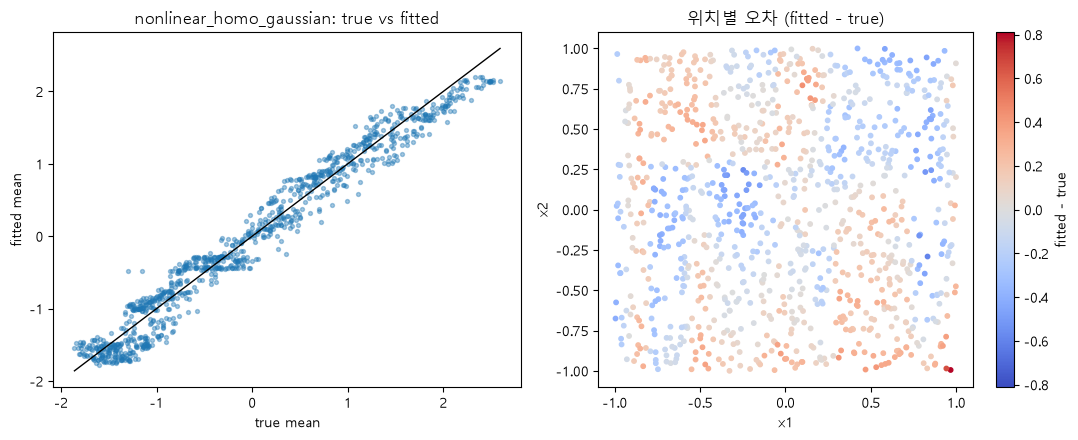

In [11]:
import matplotlib.pyplot as plt

from matplotlib import font_manager

# Windows 한글 폰트가 있으면 사용, 다른 환경에서는 영문 제목 사용
has_korean_font = any(f.name == "Malgun Gothic" for f in font_manager.fontManager.ttflist)
if has_korean_font:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # Malgun Gothic에서 유니코드 마이너스 기호가 깨지는 문제 방지

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# 산점도: true mean vs fitted mean — 대각선에서 벗어난 정도가 근사 오차
axes[0].scatter(true_mean_train, train_pred, s=8, alpha=0.4)
lims = [min(true_mean_train.min(), train_pred.min()), max(true_mean_train.max(), train_pred.max())]
axes[0].plot(lims, lims, color="black", linewidth=1)
axes[0].set_xlabel("true mean")
axes[0].set_ylabel("fitted mean")
axes[0].set_title(f"{training_dgp.name}: true vs fitted")

# 위치별 오차: (x1, x2) 위치에 fitted - true 값을 색으로 표시
# 같은 크기의 양·음 오차가 대칭 색으로 표시되도록 0 중심 범위 적용
color_limit = float(np.max(np.abs(delta)))
if color_limit == 0:
    color_limit = 1.0  # 모든 오차가 0일 때 시각화 범위만 설정, 실제 오차는 변경하지 않음
sc = axes[1].scatter(
    training_x[:, 0], training_x[:, 1], c=delta,
    cmap="coolwarm", vmin=-color_limit, vmax=color_limit, s=10,
)
plt.colorbar(sc, ax=axes[1], label="fitted - true")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")
axes[1].set_title("위치별 오차 (fitted - true)" if has_korean_font else "Local error (fitted - true)")

plt.tight_layout()
plt.show()

## 8. 잔차분산 추정 — $\hat\sigma^2$

Training residual `training_y - train_pred`의 평균제곱 SSE/n을 임시 추정 규칙으로 사용
RF의 분모·보정 규칙은 아직 미정이며 확정된 불편추정량으로 해석하지 않음

- In-sample과 OOB 모두 같은 training 데이터의 반응값 사용, 예측에 사용하는 트리의 구성이 다름
- 현재 MC에 사용할 값은 in-sample SSE/n으로 계산한 `sigma2_hat`
- OOB 잔차 평균제곱은 참고 지표이며 순수 noise variance와 동일시하거나 자동 대체하지 않음
- 잔차 평균제곱은 잔차 평균을 뺀 표본분산과 구분
- True 분산과의 차이는 이번 실행의 추정오차이며 한 번의 결과로 추정량의 편향을 단정하지 않음
- 비유한 값·음수는 오류, 0은 퇴화 상태로 기록하며 작은 양수로 강제 변경하지 않음


In [12]:
train_residual = training_y - train_pred  # in-sample residual, 관측 y 기준
n_used = train_residual.shape[0]

# SSE/n — 현재 임시 추정 규칙, RF의 불편분산 추정량으로 확정한 것은 아님
sigma2_hat = float(np.mean(train_residual ** 2))
if not np.isfinite(sigma2_hat) or sigma2_hat < 0:
    raise ValueError(f"sigma2_hat이 비유한 또는 음수입니다: {sigma2_hat}")

degenerate = (sigma2_hat == 0)
if degenerate:
    print("sigma2_hat == 0: 퇴화 구간 상태 — MC 구간 폭 0에 대한 별도 처리 필요")

# MC 난수 생성 시 scale에는 분산이 아닌 표준편차 사용
sigma_hat = float(np.sqrt(sigma2_hat))
variance_estimate = {
    "estimator": "in_sample_sse_over_n",
    "denominator": n_used,
    "n_used": n_used,
    "sigma2_hat": sigma2_hat,
    "status": "구현 제안값 - variance_estimator_by_model 사용자 확정 아님",
    "degenerate": degenerate,
}

true_variance_train = training_dgp.scale_fn(training_x) ** 2
# 이 training 위치들에서의 평균 true noise variance
design_noise_variance = float(np.mean(true_variance_train))
# 모집단 평균: 이분산에서는 유한 입력 평균과 다를 수 있음
population_noise_variance = 1.0
variance_gap_design = sigma2_hat - design_noise_variance

# 같은 training_y에 대한 OOB 예측 잔차 — 평균을 빼지 않은 평균제곱
# 함수 예측오차도 포함하며, 현재 채택한 sigma2_hat을 대체하지 않음
oob_residual = training_y - fitted_model.oob_prediction_
oob_residual_mse = float(np.mean(oob_residual ** 2))

print(f"training residual 표본 수: {n_used}")
print(f"sigma2_hat (SSE/n, in-sample): {sigma2_hat:.6f}")
print(f"sigma_hat (MC 생성용 표준편차): {sigma_hat:.6f}")
print(f"design_noise_variance (training 위치 기준): {design_noise_variance:.4f}")
print(f"population_noise_variance (모집단 기준): {population_noise_variance:.4f}")
print(f"variance_gap_design: {variance_gap_design:.6f}")
print(f"[참고] OOB 잔차 평균제곱: {oob_residual_mse:.6f}")

variance_diagnostics = pd.DataFrame([{
    "scenario": training_dgp.name,
    "model": "random_forest",
    "b": 0,
    "estimator": variance_estimate["estimator"],
    "denominator": n_used,
    "n_used": n_used,
    "status": variance_estimate["status"],
    "degenerate": degenerate,
    "design_noise_variance": design_noise_variance,
    "population_noise_variance": population_noise_variance,
    "sigma2_hat": sigma2_hat,
    "sigma_hat": sigma_hat,
    "variance_gap_design": variance_gap_design,
    "oob_residual_mse": oob_residual_mse,
}])
variance_diagnostics


training residual 표본 수: 1000
sigma2_hat (SSE/n, in-sample): 0.941771
sigma_hat (MC 생성용 표준편차): 0.970449
design_noise_variance (training 위치 기준): 1.0000
population_noise_variance (모집단 기준): 1.0000
variance_gap_design: -0.058229
[참고] OOB 잔차 평균제곱: 1.074580


,scenario,model,b,estimator,denominator,n_used,status,degenerate,design_noise_variance,population_noise_variance,sigma2_hat,sigma_hat,variance_gap_design,oob_residual_mse
0,nonlinear_homo_gaussian,random_forest,0,in_sample_sse_over_n,1000,1000,구현 제안값 - variance_estimator_by_model 사용자 확정 아님,False,1.0,1.0,0.941771,0.970449,-0.058229,1.07458


## 다음 단계

`fitted_model`, `train_pred`, `sigma2_hat`을 고정한 뒤 MC 구간 생성과 별도 calibration을 이용한 CP 구간 구성
MC에는 `sigma_hat = sqrt(sigma2_hat)` 사용
Training 반응값을 coverage 평가에 재사용하지 않고 true DGP의 독립적인 새 반응값 생성

현재 노트북은 잔차분산 추정까지 수행하며 MC·CP 구간 생성 및 coverage 평가는 아직 수행하지 않음